Pull data from CSV file with image frame timestamps and states, the state_1 is the first pipe classification 1 = straight, state_2 is the second classification.

In [354]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

file_path = '/content/drive/MyDrive/PIPEDATA/DS11/states.csv'
df_states = pd.read_csv(file_path)

display(df_states.head(6))

,timestamp,state_1,state_2
0,2,1,0
1,544,1,0
2,1181,1,0
3,1759,1,0
4,2359,1,0
5,2976,1,0


check number of junctions

In [355]:
state_1_changes = (df_states['state_1'].diff() != 0).sum()
pipe_junctions = (state_1_changes-1)/2
print(f"Number of Junctions: {pipe_junctions}")

Number of Junctions: 2.0


find timestamps

In [356]:
state_1_change_indices = df_states['state_1'].diff() != 0
timestamps_at_state_1_changes = df_states.loc[state_1_change_indices, 'timestamp'].tolist()

# Add the very last timestamp from the DataFrame to ensure the last interval is captured
last_timestamp = df_states['timestamp'].iloc[-1]
if last_timestamp not in timestamps_at_state_1_changes:
    timestamps_at_state_1_changes.append(int(last_timestamp))

print("Timestamps where state_1 changes:")
print(timestamps_at_state_1_changes)

Timestamps where state_1 changes:
[2, 111302, 146176, 194055, 274298, 289344]


Find the upcoming junction based on the modal state2 in straight sections only - bear in mind that the junction predictions for in-junction images are ignored.

In [357]:
modal_values_per_interval = []

for i in range(len(timestamps_at_state_1_changes) - 1):
    start_timestamp = timestamps_at_state_1_changes[i]
    end_timestamp = timestamps_at_state_1_changes[i+1]

    current_interval_df = df_states[(df_states['timestamp'] >= start_timestamp) &
                                    (df_states['timestamp'] <= end_timestamp)]

    # Calculate the mode for 'state_1' and 'state_2'
    # .mode().iloc[0] handles cases where there might be multiple modes by picking the first one
    mode_state_1 = current_interval_df['state_1'].mode().iloc[0]
    mode_state_2 = current_interval_df['state_2'].mode().iloc[0]

    modal_values_per_interval.append({
        'start_timestamp': start_timestamp,
        'end_timestamp': end_timestamp,
        'mode_state_1': mode_state_1,
        'mode_state_2': mode_state_2
    })

print("Modal values per interval:")
for item in modal_values_per_interval:
    print(item)

Modal values per interval:
{'start_timestamp': 2, 'end_timestamp': 111302, 'mode_state_1': np.int64(1), 'mode_state_2': np.int64(0)}
{'start_timestamp': 111302, 'end_timestamp': 146176, 'mode_state_1': np.int64(0), 'mode_state_2': np.int64(0)}
{'start_timestamp': 146176, 'end_timestamp': 194055, 'mode_state_1': np.int64(1), 'mode_state_2': np.int64(1)}
{'start_timestamp': 194055, 'end_timestamp': 274298, 'mode_state_1': np.int64(0), 'mode_state_2': np.int64(1)}
{'start_timestamp': 274298, 'end_timestamp': 289344, 'mode_state_1': np.int64(1), 'mode_state_2': np.int64(2)}


In [358]:
df_intervals = pd.DataFrame(modal_values_per_interval)
df_intervals = df_intervals.rename(columns={
    'start_timestamp': 'timestamp1',
    'end_timestamp': 'timestamp2',
    'mode_state_1': 'mode state_1'
})

display(df_intervals.head())

,timestamp1,timestamp2,mode state_1,mode_state_2
0,2,111302,1,0
1,111302,146176,0,0
2,146176,194055,1,1
3,194055,274298,0,1
4,274298,289344,1,2


In [359]:
file_path_imu = '/content/drive/MyDrive/PIPEDATA/DS11/imu.txt'
df_imu = pd.read_csv(file_path_imu, header=None, sep=None, engine='python')
display(df_imu.head())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,15:31:22.056,->,2/X:,2.66,Y:,-8.61,Z:,-4.56\X:,1.25,Y:,0.12,Z:,1.63\X:,122.56,Y:,16.19,Z:,118.06\0
1,15:31:22.153,->,110/X:,2.63,Y:,-8.57,Z:,-4.54\X:,1.12,Y:,0.19,Z:,1.44\X:,122.50,Y:,16.19,Z:,118.06\2
2,15:31:22.282,->,218/X:,2.60,Y:,-8.47,Z:,-4.46\X:,1.37,Y:,0.06,Z:,1.50\X:,122.50,Y:,16.19,Z:,118.06\2
3,15:31:22.379,->,325/X:,2.51,Y:,-7.99,Z:,-3.98\X:,1.44,Y:,0.31,Z:,1.56\X:,122.50,Y:,16.19,Z:,118.06\2
4,15:31:22.475,->,434/X:,2.54,Y:,-8.04,Z:,-4.02\X:,1.31,Y:,0.31,Z:,1.56\X:,122.50,Y:,16.19,Z:,118.06\3


We need to create a new data frame object, for this we populate it with the data read from the serial txt file (as shown above)

In [360]:
split_col_17 = df_imu[17].str.split(r'\\', expand=True)

new_df_imu = pd.DataFrame({
    'timestamp': df_imu[0],
    'sequence number': split_col_17[1].fillna(0).astype(int), # Extract sequence number after splitting
    'accX': df_imu[3].astype(float),
    'accY': df_imu[5].astype(float),
    'accZ': df_imu[7].str.replace(r'\\X:', '', regex=True).astype(float),
    'gyroX': df_imu[8].astype(float),
    'gyroY': df_imu[10].astype(float),
    'gyroZ': df_imu[12].str.replace(r'\\X:', '', regex=True).astype(float),
    'filterX': df_imu[13].astype(float),
    'filterY': df_imu[15].astype(float),
    'filterZ': split_col_17[0].astype(float) # Extract filterZ after splitting
})

# Convert 'timestamp' column to total milliseconds
new_df_imu['timestamp'] = pd.to_datetime(new_df_imu['timestamp'], format='%H:%M:%S.%f').apply(lambda x: x.hour * 3600 * 1000 + x.minute * 60 * 1000 + x.second * 1000 + x.microsecond // 1000)

# Create 'timestamp2' column with millisecond difference from the first timestamp
new_df_imu['timestamp2'] = new_df_imu['timestamp'] - new_df_imu['timestamp'].iloc[0]

display(new_df_imu.tail(20))

,timestamp,sequence number,accX,accY,accZ,gyroX,gyroY,gyroZ,filterX,filterY,filterZ,timestamp2
2606,56164928,6,2.53,-9.33,0.62,-0.94,-0.19,0.06,238.25,15.50,85.75,282872
2607,56165025,6,2.60,-9.33,0.78,-0.94,-0.19,-0.06,238.25,15.50,85.75,282969
2608,56165122,6,2.54,-9.26,0.75,0.44,0.12,0.12,238.31,15.50,85.81,283066
2609,56165251,6,2.51,-9.24,0.71,0.50,0.12,0.31,238.31,15.50,85.81,283195
2610,56165349,6,2.47,-9.22,0.67,0.69,0.50,0.25,238.31,15.50,85.87,283293
2611,56165445,6,2.48,-9.25,0.64,0.63,0.44,0.25,238.31,15.50,85.87,283389
2612,56165573,6,2.50,-9.31,0.61,0.56,0.50,0.37,238.31,15.50,85.94,283517
2613,56165669,6,2.87,-9.75,0.71,0.63,0.44,0.19,238.31,15.50,85.94,283613
2614,56165766,6,2.86,-9.71,0.73,0.69,0.44,0.25,238.31,15.50,85.94,283710
2615,56165895,6,2.81,-9.67,0.77,-1.00,-0.25,-0.12,238.31,15.50,85.94,283839


In [361]:
# Calculate pitch angle based on accelerometer data
# Pitch = atan2(accY, sqrt(accX^2 + accZ^2))
new_df_imu['pitch_angle_acc'] = np.degrees(np.arctan2(new_df_imu['accZ'], np.sqrt(new_df_imu['accX']**2 + new_df_imu['accY']**2)))
new_df_imu['roll_angle_acc'] = np.degrees(np.arctan2(new_df_imu['accX'], np.sqrt(new_df_imu['accY']**2 + new_df_imu['accZ']**2)))

display(new_df_imu.head(1500))

,timestamp,sequence number,accX,accY,accZ,gyroX,gyroY,gyroZ,filterX,filterY,filterZ,timestamp2,pitch_angle_acc,roll_angle_acc
0,55882056,0,2.66,-8.61,-4.56,1.25,0.12,1.63,122.56,16.19,118.06,0,-26.840246,15.270570
1,55882153,2,2.63,-8.57,-4.54,1.12,0.19,1.44,122.50,16.19,118.06,97,-26.859639,15.172694
2,55882282,2,2.60,-8.47,-4.46,1.37,0.06,1.50,122.50,16.19,118.06,226,-26.719853,15.195613
3,55882379,2,2.51,-7.99,-3.98,1.44,0.31,1.56,122.50,16.19,118.06,323,-25.418251,15.705377
4,55882475,3,2.54,-8.04,-4.02,1.31,0.31,1.56,122.50,16.19,118.06,419,-25.490565,15.778583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,56044336,3,4.91,-9.11,0.44,-0.88,1.37,-4.81,152.94,25.12,83.50,162280,2.434550,28.295385
1496,56044433,3,4.44,-9.32,0.57,0.25,1.56,-4.56,153.06,25.19,83.44,162377,3.160291,25.431386
1497,56044530,3,4.11,-9.17,0.48,-2.63,2.25,-5.69,153.13,25.25,83.37,162474,2.734728,24.112711
1498,56044659,3,3.19,-8.54,1.91,-2.13,1.81,-5.88,153.19,25.25,83.31,162603,11.833099,20.028340


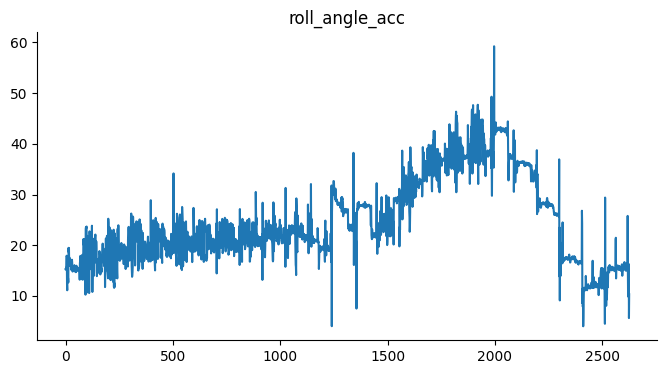

In [362]:
from matplotlib import pyplot as plt
new_df_imu['roll_angle_acc'].plot(kind='line', figsize=(8, 4), title='roll_angle_acc')
plt.gca().spines[['top', 'right']].set_visible(False)

Here we are checking the kinematic gait model

Function 'calculate_y_from_matlab_snippet' updated successfully.
Resulting y: 53.71346133669985


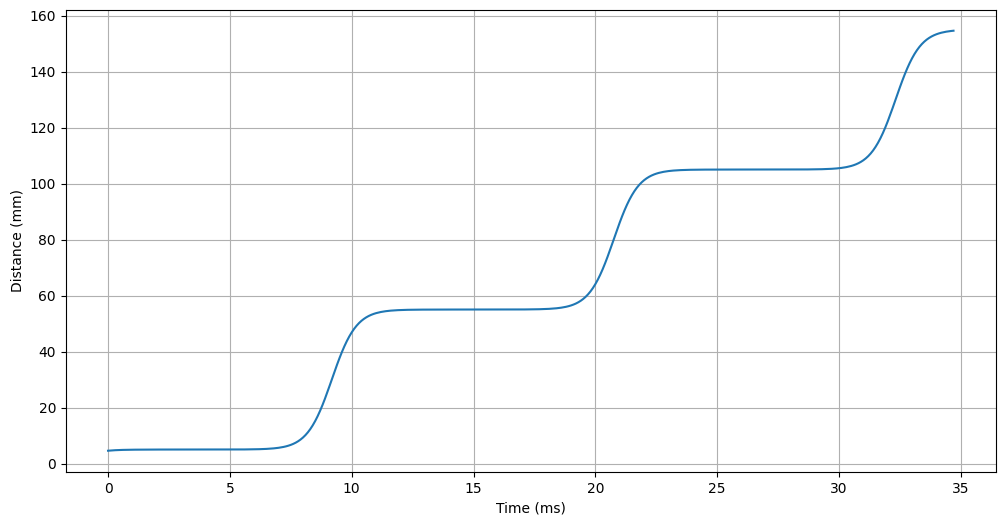

In [363]:
def calculate_y_from_matlab_snippet(x, period, distance, actuation_start, actuation_period):
    x_ = np.remainder(x, period)
    mod = (x - x_) / (period*2) * distance
    y_ = distance * (0.5 + 0.5 * float(np.tanh(((x_ - actuation_start + (actuation_period / 2)))) / 2))
    y = 2*(y_ + mod - 10)
    return y


print("Function 'calculate_y_from_matlab_snippet' updated successfully.")

# Variables
period_val = 11.570
distance_val = 50
actuation_start_val = 8.683
actuation_period_val = 3.000
x_val = 9
result_y = calculate_y_from_matlab_snippet(x_val, period_val, distance_val, actuation_start_val, actuation_period_val)
print(f"Resulting y: {result_y}")

# Lists to store results for plotting
t_values = []
results = []

# Loop through t_val using np.arange to handle float period_val
# np.arange(start, stop, step) generates values from start up to (but not including) stop
for t_val in np.arange(0, 3 * period_val, step=0.1): # Using a small step for better plot resolution
    result = calculate_y_from_matlab_snippet((t_val-2), period_val, distance_val, actuation_start_val, actuation_period_val)
    t_values.append(t_val)
    results.append(result)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(t_values, results)
plt.xlabel('Time (ms)')
plt.ylabel('Distance (mm)')
plt.grid(True)
plt.show()

We use the model to find the distance - this is dx from the start (the offset is just caused by where it starts in the function and isnt relavant/affect anything)

In [364]:
new_df_imu['distance est'] = new_df_imu['timestamp2'].apply(lambda x: calculate_y_from_matlab_snippet(((x/1000)), period_val, distance_val, actuation_start_val, actuation_period_val))
# Initialize new columns in new_df_imu with NaN values
new_df_imu['dx'] = 0
new_df_imu['dx'] = new_df_imu['distance est'].diff()
new_df_imu['dx2'] = new_df_imu['dx'].diff()
display(new_df_imu.head())

,timestamp,sequence number,accX,accY,accZ,gyroX,gyroY,gyroZ,filterX,filterY,filterZ,timestamp2,pitch_angle_acc,roll_angle_acc,distance est,dx,dx2
0,55882056,0,2.66,-8.61,-4.56,1.25,0.12,1.63,122.56,16.19,118.06,0,-26.840246,15.270570,5.000029,NaN,NaN
1,55882153,2,2.63,-8.57,-4.54,1.12,0.19,1.44,122.50,16.19,118.06,97,-26.859639,15.172694,5.000035,0.000006,NaN
2,55882282,2,2.60,-8.47,-4.46,1.37,0.06,1.50,122.50,16.19,118.06,226,-26.719853,15.195613,5.000045,0.000010,4.130643e-06
3,55882379,2,2.51,-7.99,-3.98,1.44,0.31,1.56,122.50,16.19,118.06,323,-25.418251,15.705377,5.000055,0.000010,-6.030139e-07
4,55882475,3,2.54,-8.04,-4.02,1.31,0.31,1.56,122.50,16.19,118.06,419,-25.490565,15.778583,5.000067,0.000012,1.943444e-06


Here i was just seeing what the madgwick filter was saying - it doesnt work well hence it was ignored.

In [365]:
# Calculate the magnitude of the filter vector for each row
new_df_imu['filter_magnitude'] = np.sqrt(new_df_imu['filterX']**2 + new_df_imu['filterY']**2 + new_df_imu['filterZ']**2)

# Calculate the normalized direction vector components
# Handle cases where magnitude might be zero to avoid division by zero
new_df_imu['filter_dirX'] = new_df_imu.apply(lambda row: np.cos(row['filterY'])*np.sin(row['filterZ']) , axis=1)
new_df_imu['filter_dirY'] = new_df_imu.apply(lambda row: np.cos(row['filterY'])*np.cos(row['filterZ']) , axis=1)
new_df_imu['filter_dirZ'] = new_df_imu.apply(lambda row: np.sin(row['filterZ']) , axis=1)


display(new_df_imu[['filterX', 'filterY', 'filterZ', 'filter_magnitude', 'filter_dirX', 'filter_dirY', 'filter_dirZ']].head())

,filterX,filterY,filterZ,filter_magnitude,filter_dirX,filter_dirY,filter_dirZ
0,122.56,16.19,118.06,170.942193,0.858447,-0.219449,-0.968844
1,122.50,16.19,118.06,170.899180,0.858447,-0.219449,-0.968844
2,122.50,16.19,118.06,170.899180,0.858447,-0.219449,-0.968844
3,122.50,16.19,118.06,170.899180,0.858447,-0.219449,-0.968844
4,122.50,16.19,118.06,170.899180,0.858447,-0.219449,-0.968844


dx2 is the acceleration squared, here we see obvious periodic motion as expected

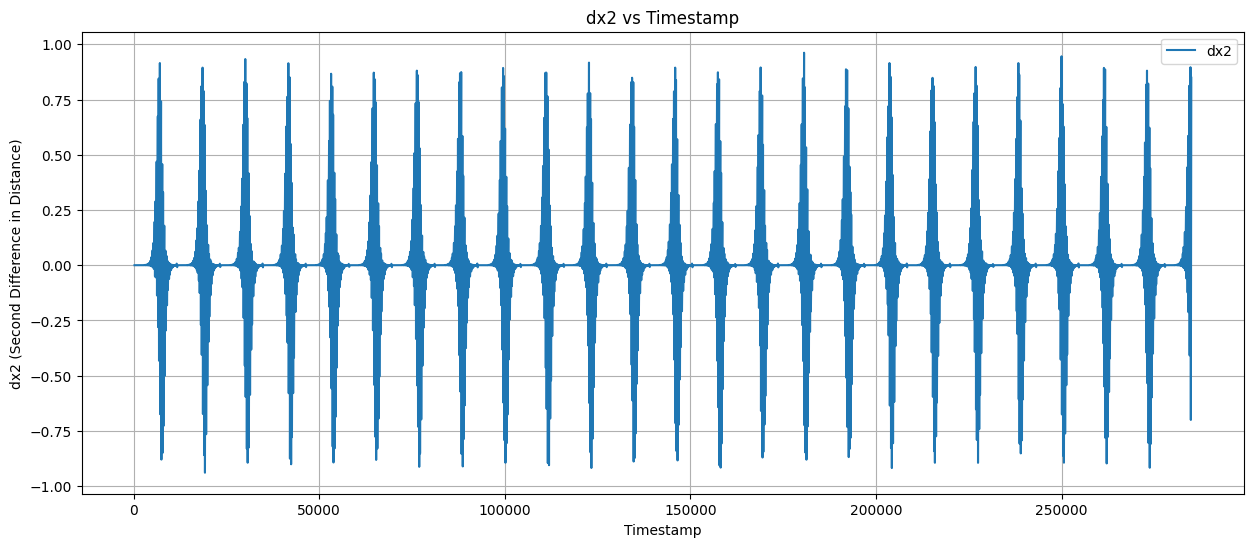

In [366]:
plt.figure(figsize=(15, 6))
plt.plot(new_df_imu['timestamp2'], new_df_imu['dx2'], label='dx2')
plt.xlabel('Timestamp')
plt.ylabel('dx2 (Second Difference in Distance)')
plt.title('dx2 vs Timestamp')
plt.grid(True)
plt.legend()
plt.show()

<Figure size 1500x700 with 0 Axes>

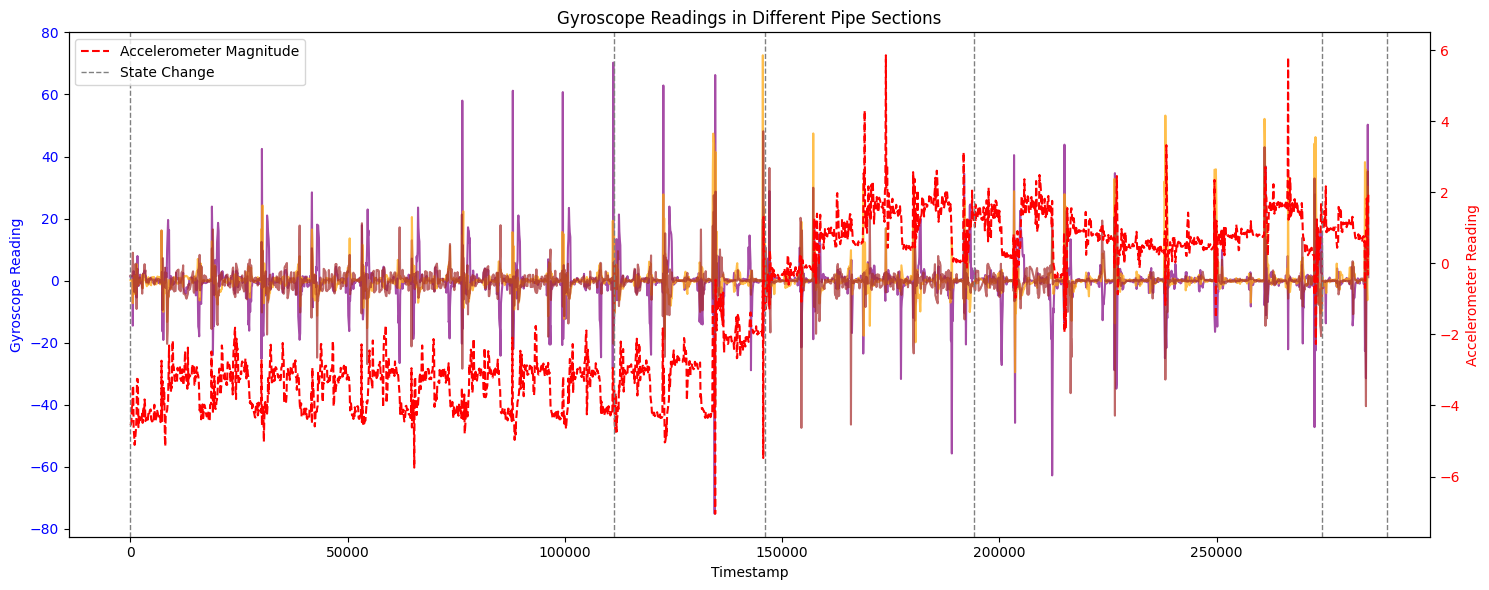

In [367]:
plt.figure(figsize=(15, 7))

fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot dx2 on the primary y-axis
# Plot gyroX
ax1.plot(new_df_imu['timestamp2'], new_df_imu['gyroX'], label='gyroX', color='purple', alpha=0.7)
# Plot gyroY
ax1.plot(new_df_imu['timestamp2'], new_df_imu['gyroY'], label='gyroY', color='orange', alpha=0.7)
# Plot gyroZ
ax1.plot(new_df_imu['timestamp2'], new_df_imu['gyroZ'], label='gyroZ', color='brown', alpha=0.7)
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Gyroscope Reading', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(new_df_imu['timestamp2'], new_df_imu['accZ'], label='Accelerometer Magnitude', color='red', linestyle='--')
ax2.set_ylabel('Accelerometer Reading', color='red')
ax2.tick_params(axis='y', labelcolor='red')


# Add vertical lines for timestamps_at_state_1_changes
for timestamp in timestamps_at_state_1_changes:
    plt.axvline(x=timestamp, color='gray', linestyle='--', linewidth=1, label='State Change' if timestamp == timestamps_at_state_1_changes[0] else "")

plt.xlabel('Timestamp')
plt.ylabel('Accelerometer Reading')
plt.title('Gyroscope Readings in Different Pipe Sections')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

In [368]:
import numpy as np

new_df_imu['acc_magnitude'] = np.sqrt(new_df_imu['accX']**2 + new_df_imu['accY']**2 + new_df_imu['accZ']**2)
display(new_df_imu.head())

,timestamp,sequence number,accX,accY,accZ,gyroX,gyroY,gyroZ,filterX,filterY,...,pitch_angle_acc,roll_angle_acc,distance est,dx,dx2,filter_magnitude,filter_dirX,filter_dirY,filter_dirZ,acc_magnitude
0,55882056,0,2.66,-8.61,-4.56,1.25,0.12,1.63,122.56,16.19,...,-26.840246,15.270570,5.000029,NaN,NaN,170.942193,0.858447,-0.219449,-0.968844,10.099569
1,55882153,2,2.63,-8.57,-4.54,1.12,0.19,1.44,122.50,16.19,...,-26.859639,15.172694,5.000035,0.000006,NaN,170.899180,0.858447,-0.219449,-0.968844,10.048552
2,55882282,2,2.60,-8.47,-4.46,1.37,0.06,1.50,122.50,16.19,...,-26.719853,15.195613,5.000045,0.000010,4.130643e-06,170.899180,0.858447,-0.219449,-0.968844,9.919299
3,55882379,2,2.51,-7.99,-3.98,1.44,0.31,1.56,122.50,16.19,...,-25.418251,15.705377,5.000055,0.000010,-6.030139e-07,170.899180,0.858447,-0.219449,-0.968844,9.272572
4,55882475,3,2.54,-8.04,-4.02,1.31,0.31,1.56,122.50,16.19,...,-25.490565,15.778583,5.000067,0.000012,1.943444e-06,170.899180,0.858447,-0.219449,-0.968844,9.340964


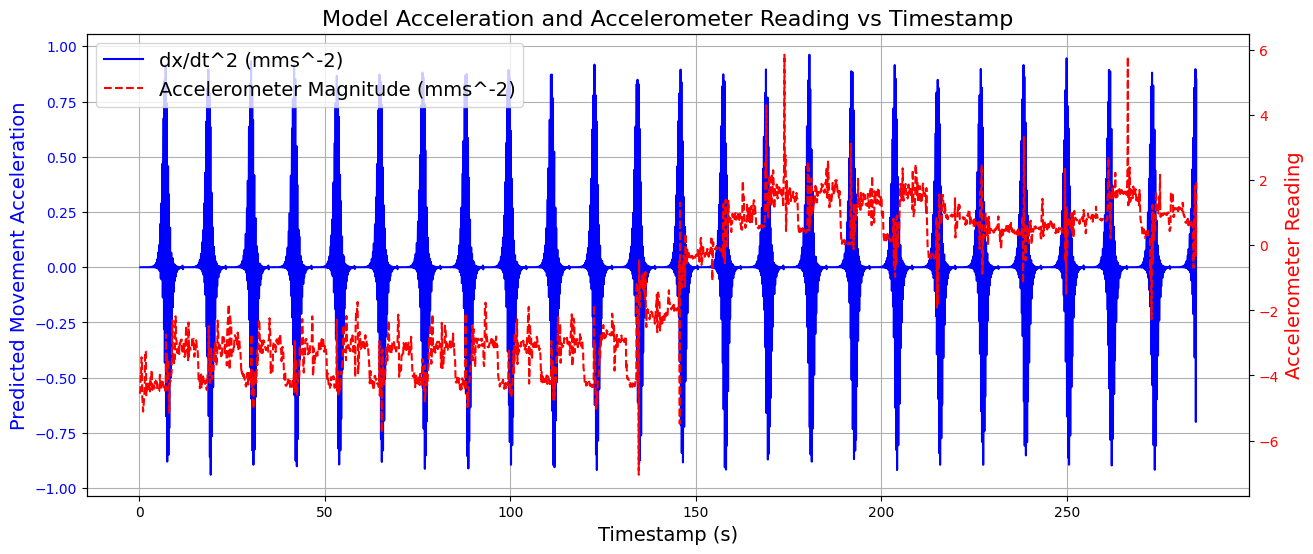

In [369]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot dx2 on the primary y-axis
ax1.plot((new_df_imu['timestamp2']/1000), new_df_imu['dx2'], label='dx/dt^2 (mms^-2)', color='blue')
ax1.set_xlabel('Timestamp (s)', fontsize=14)
ax1.set_ylabel('Predicted Movement Acceleration', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot((new_df_imu['timestamp2']/1000), new_df_imu['accZ'], label='Accelerometer Magnitude (mms^-2)', color='red', linestyle='--')
ax2.set_ylabel('Accelerometer Reading', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')

# Add title and grid
plt.title('Model Acceleration and Accelerometer Reading vs Timestamp', fontsize=16)
ax1.grid(True)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=14)

plt.show()

Here we are checking what are **acceleration model** thinks the acceleration is - if it is **LOW** then the pitch values from the **accelerometer** are used

In [370]:
def custom_combined_pitch_logic(dx2_value, pitch_angle_acc_value):

    if dx2_value > 0.01 or dx2_value < -0.1:
        return pitch_angle_acc_value
    else:
        return np.nan # Return NaN to be filled by ffill

# We use axis=1 to apply the function row-wise
new_df_imu['Combined_Pitch_Variable'] = new_df_imu.apply(lambda row: custom_combined_pitch_logic(row['dx2'], row['pitch_angle_acc']), axis=1)

# Now, forward-fill the NaN values to get the 'last valid' value
new_df_imu['Combined_Pitch_Variable'] = new_df_imu['Combined_Pitch_Variable'].ffill()

# We use axis=1 to apply the function row-wise
new_df_imu['Combined_Roll_Variable'] = new_df_imu.apply(lambda row: custom_combined_pitch_logic(row['dx2'], row['roll_angle_acc']), axis=1)

# Now, forward-fill the NaN values to get the 'last valid' value
new_df_imu['Combined_Roll_Variable'] = new_df_imu['Combined_Roll_Variable'].ffill()

# Display the DataFrame with the new column
display(new_df_imu.head())

,timestamp,sequence number,accX,accY,accZ,gyroX,gyroY,gyroZ,filterX,filterY,...,distance est,dx,dx2,filter_magnitude,filter_dirX,filter_dirY,filter_dirZ,acc_magnitude,Combined_Pitch_Variable,Combined_Roll_Variable
0,55882056,0,2.66,-8.61,-4.56,1.25,0.12,1.63,122.56,16.19,...,5.000029,NaN,NaN,170.942193,0.858447,-0.219449,-0.968844,10.099569,NaN,NaN
1,55882153,2,2.63,-8.57,-4.54,1.12,0.19,1.44,122.50,16.19,...,5.000035,0.000006,NaN,170.899180,0.858447,-0.219449,-0.968844,10.048552,NaN,NaN
2,55882282,2,2.60,-8.47,-4.46,1.37,0.06,1.50,122.50,16.19,...,5.000045,0.000010,4.130643e-06,170.899180,0.858447,-0.219449,-0.968844,9.919299,NaN,NaN
3,55882379,2,2.51,-7.99,-3.98,1.44,0.31,1.56,122.50,16.19,...,5.000055,0.000010,-6.030139e-07,170.899180,0.858447,-0.219449,-0.968844,9.272572,NaN,NaN
4,55882475,3,2.54,-8.04,-4.02,1.31,0.31,1.56,122.50,16.19,...,5.000067,0.000012,1.943444e-06,170.899180,0.858447,-0.219449,-0.968844,9.340964,NaN,NaN


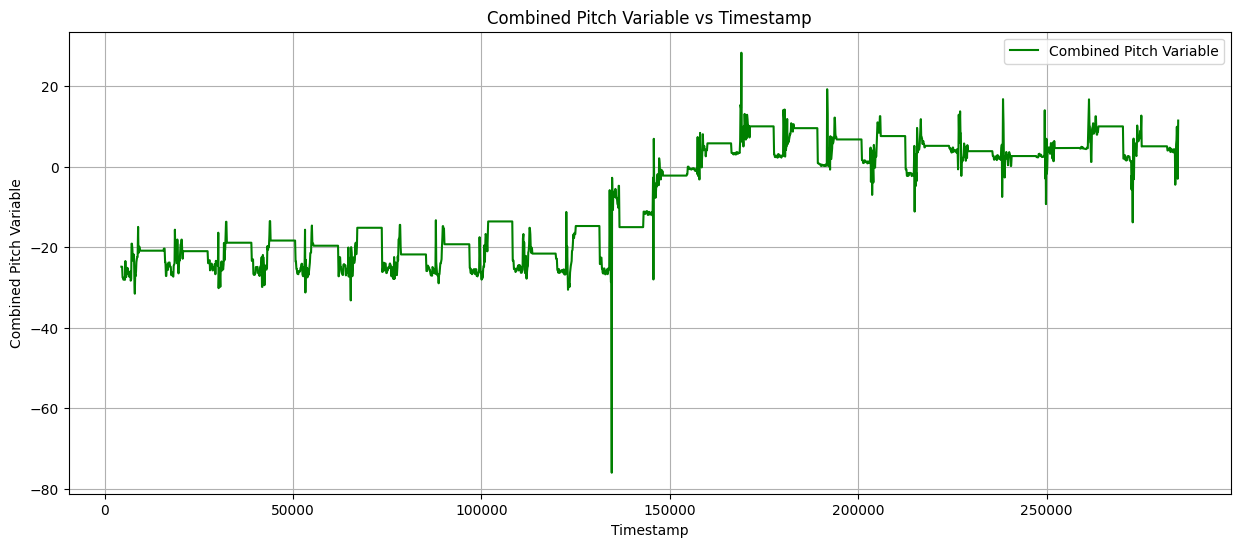

In [371]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(new_df_imu['timestamp2'], new_df_imu['Combined_Pitch_Variable'], label='Combined Pitch Variable', color='green')
plt.xlabel('Timestamp')
plt.ylabel('Combined Pitch Variable')
plt.title('Combined Pitch Variable vs Timestamp')
plt.grid(True)
plt.legend()
plt.show()

In [372]:
import numpy as np

# Initialize new columns in new_df_imu with NaN values
new_df_imu['straight'] = 1
new_df_imu['mode_state_2_from_interval'] = np.nan

# Iterate through each interval in df_intervals
for index, interval_row in df_intervals.iterrows():
    start_ts = interval_row['timestamp1']
    end_ts = interval_row['timestamp2']
    mode_s1 = interval_row['mode state_1']
    mode_s2 = interval_row['mode_state_2']

    # Create a mask for rows in new_df_imu where timestamp2 falls within the current interval
    mask = (new_df_imu['timestamp2'] >= start_ts) & (new_df_imu['timestamp2'] <= end_ts)

    # Assign the mode values to the corresponding rows in new_df_imu
    new_df_imu.loc[mask, 'straight'] = mode_s1
    new_df_imu.loc[mask, 'junction ahead'] = mode_s2

display(new_df_imu.loc[:,['straight', 'junction ahead']].head(100))

,straight,junction ahead
0,1,NaN
1,1,0.0
2,1,0.0
3,1,0.0
4,1,0.0
...,...,...
95,1,0.0
96,1,0.0
97,1,0.0
98,1,0.0


In [373]:
display(new_df_imu[['straight', 'junction ahead']].head())

,straight,junction ahead
0,1,NaN
1,1,0.0
2,1,0.0
3,1,0.0
4,1,0.0


In [374]:
total_dx_for_straight = new_df_imu[new_df_imu['straight'] == 1]['dx'].sum()
print(f"Total distance moved bar junction lengths is: {total_dx_for_straight/1000}m")

Total distance moved bar junction lengths is: 0.7276138244087947m


It is easier to **split the data frane into segments** according to the structure to calculate the distances and angles.

In [375]:
# Initialize an empty list to store the split DataFrames
split_dfs = []

# Iterate through each interval in df_intervals
for i, interval_row in df_intervals.iterrows():
    start_ts = interval_row['timestamp1']
    end_ts = interval_row['timestamp2']

    # Filter new_df_imu for the current interval
    current_df_section = new_df_imu[(new_df_imu['timestamp2'] >= start_ts) & (new_df_imu['timestamp2'] <= end_ts)].copy()
    split_dfs.append(current_df_section)

# Assign the split DataFrames to df_1, df_2, df_3, df_4
df_1 = split_dfs[0]
df_2 = split_dfs[1]
df_3 = split_dfs[2]
df_4 = split_dfs[3]
df_5 = split_dfs[4]

#print("new_df_imu has been split into df_1, df_2, df_3, and df_4.")
#print(f"df_1 head:\n{df_1.head()}")
print(f"df_2 head:\n{df_2.head(100)}")
print(f"df_3 head:\n{df_3.head()}")
#print(f"df_4 head:\n{df_4.head()}")

df_2 head:
      timestamp  sequence number  accX   accY  accZ  gyroX  gyroY  gyroZ  \
1026   55993406                7  3.73  -9.81 -3.57 -11.81  14.31 -10.25   
1027   55993535                7  4.28  -8.96 -4.51   5.94 -10.44  -5.44   
1028   55993631                7  4.00  -8.66 -4.74  -4.00   2.63   5.13   
1029   55993728                7  4.08 -10.28 -3.66  -1.12  -2.94  -2.88   
1030   55993858                7  3.93  -8.49 -3.81  13.06   4.69   1.00   
...         ...              ...   ...    ...   ...    ...    ...    ...   
1121   56003724                6  3.61  -8.04 -4.21  -0.06  -0.06  -0.06   
1122   56003852                6  3.64  -8.03 -4.21  -0.63   0.19   0.00   
1123   56003949                6  3.67  -8.04 -4.25  -0.25  -0.06   0.19   
1124   56004046                6  3.48  -7.91 -4.35  -0.12  -0.37   0.19   
1125   56004175                6  3.46  -7.93 -4.33  -0.56   0.12   0.12   

      filterX  filterY  ...  filter_magnitude  filter_dirX  filter_dirY  \
1

Here we are finding the pitch values at the three straight segments

In [376]:
avg_cpv_df1 = df_1['Combined_Pitch_Variable'].mean()
avg_paa_df1 = df_1['pitch_angle_acc'].mean()
print(f"df_1 - Average Combined_Pitch_Variable: {avg_cpv_df1}")
print(f"df_1 - Average pitch_angle_acc: {avg_paa_df1}\n")

avg_cpv_df3 = df_3['Combined_Pitch_Variable'].mean()
avg_paa_df3 = df_3['pitch_angle_acc'].mean()
print(f"df_3 - Average Combined_Pitch_Variable: {avg_cpv_df3}")
print(f"df_3 - Average pitch_angle_acc: {avg_paa_df3}")

avg_cpv_df5 = df_5['Combined_Pitch_Variable'].mean()
avg_paa_df5 = df_5['pitch_angle_acc'].mean()
print(f"df_5 - Average Combined_Pitch_Variable: {avg_cpv_df5}")
print(f"df_5 - Average pitch_angle_acc: {avg_paa_df5}")

df_1 - Average Combined_Pitch_Variable: -21.17973602611441
df_1 - Average pitch_angle_acc: -21.401342367115912

df_3 - Average Combined_Pitch_Variable: 4.776664827951721
df_3 - Average pitch_angle_acc: 4.883527743285213
df_5 - Average Combined_Pitch_Variable: 5.033281731961962
df_5 - Average pitch_angle_acc: 5.65900808561581


In [377]:
total_dx_for_straight = df_3[new_df_imu['straight'] == 1]['dx'].sum()
print(f"Total distance moved bar junction lengths is: {total_dx_for_straight/1000}m")

Total distance moved bar junction lengths is: 0.2212847425123913m


/tmp/ipykernel_1321/2545831625.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [378]:
sum_dx_df1 = df_1['dx'].sum()
sum_dx_df3 = df_3['dx'].sum()
sum_dx_df5 = df_5['dx'].sum()

print(f"Sum of 'dx' for df_1: {sum_dx_df1}")
print(f"Sum of 'dx' for df_3: {sum_dx_df3}")
print(f"Sum of 'dx' for df_5: {sum_dx_df5}")

#493.38
#204.87
#45.66

#492.83
#249.77
#186.67

#493.84
#283.87
#198.54


Sum of 'dx' for df_1: 473.50176857841313
Sum of 'dx' for df_3: 221.2847425123913
Sum of 'dx' for df_5: 32.827313317990274




---


***The above code is repeated for each of the dataframes I was looking at the results are noted for plotting --- there is an effective break between these two codes - ABOVE: find distance and angles BELOW: Create graph and use angle optimisation.***

---



In [379]:
p1 = -25
p2 = 0
p3 = 0

ds1_p1 = -24.29123795032235
ds1_p2 = 4.440225255822763 # 0.07 rad
ds1_p3 = 6.516240473640311 # 0.1 rad

cnn_p1 = -21.17973602611441
cnn_p2 = 4.77
cnn_p3 = 5.033281731961962

ds2_p1 = -25.317088248157702
ds2_p2 = -2.0515054013874856
ds2_p3 = 5.392831299791084

#avg error = 4.6 degrees

_p1 = np.array([0, 0])
_p2 = np.array([10 * np.cos(np.radians(p1)), 10 * np.sin(np.radians(p1))])
_p3 = _p2 + np.array([10, 0])
_p4 = _p3 + np.array([10, 0])

## Points on map / not used
d1_p1 = np.array([0, 0])
d1_p2 = np.array([10 * np.cos(np.radians(ds1_p1)), 10 * np.sin(np.radians(ds1_p1))])
d1_p3 = d1_p2 + np.array([10 * np.cos(np.radians(ds1_p2)), 10 * np.sin(np.radians(ds1_p2))])
d1_p4 = d1_p3 + np.array([10 * np.cos(np.radians(ds1_p3)), 10 * np.sin(np.radians(ds1_p3))])

d2_p1 = np.array([0, 0])
d2_p2 = np.array([10* np.cos(np.radians(ds2_p1)), 10 * np.sin(np.radians(ds2_p1))])
d2_p3 = d2_p2 + np.array([10 * np.cos(np.radians(ds2_p2)), 10 * np.sin(np.radians(ds2_p2))])
d2_p4 = d2_p3 + np.array([10 * np.cos(np.radians(ds2_p3)), 10 * np.sin(np.radians(ds2_p3))])

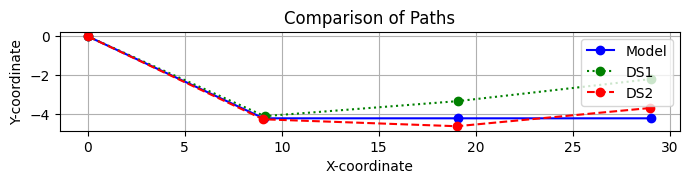

In [380]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot Model path
model_x = [_p1[0], _p2[0], _p3[0], _p4[0]]
model_y = [_p1[1], _p2[1], _p3[1], _p4[1]]
plt.plot(model_x, model_y, marker='o', linestyle='-', color='blue', label='Model')

# Plot DS1 path
ds1_x = [d1_p1[0], d1_p2[0], d1_p3[0], d1_p4[0]]
ds1_y = [d1_p1[1], d1_p2[1], d1_p3[1], d1_p4[1]]
plt.plot(ds1_x, ds1_y, marker='o', linestyle=':', color='green', label='DS1')

# Plot DS2 path
ds2_x = [d2_p1[0], d2_p2[0], d2_p3[0], d2_p4[0]]
ds2_y = [d2_p1[1], d2_p2[1], d2_p3[1], d2_p4[1]]
plt.plot(ds2_x, ds2_y, marker='o', linestyle='--', color='red', label='DS2')

plt.title('Comparison of Paths')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal scaling for x and y axes
plt.legend(loc = 'upper right')
plt.show()

Here we are finding the following equations, notice for this example the junction angle is 135 degrees - this is for a 45 degree bend:


\begin{equation}
u_i = v_{P_{2}}(\zeta_i) = \cos(\psi_{J})v_{P_{1}} + \sin(\psi_{J})\left(\cos(\zeta_i)\hat{a} + \sin(\zeta_i)\hat{b}\right)
\label{vectors}
\end{equation}



In [381]:
# 1. Define the given vector
v = np.array([0, np.cos(np.radians(0)), np.sin(np.radians(-cnn_p1))])

# 2. Normalize the given vector
v_norm = np.linalg.norm(v)
v_hat = v / v_norm

# 3. Define the desired angle (135 degrees)
angle_degrees = 135
angle_radians = np.radians(angle_degrees)

# Cosine and sine of the desired angle
cos_alpha = np.cos(angle_radians)
sin_alpha = np.sin(angle_radians)

# 4. Find two orthonormal vectors (a, b) that are orthogonal to v_hat.
# These vectors will form a basis for the plane perpendicular to v_hat.
# We use cross products for this, ensuring 'a' is not parallel to 'v_hat'.
temp_vec = np.array([1, 0, 0])
# If v_hat is parallel to temp_vec, choose another arbitrary vector (e.g., [0,0,1])
if np.allclose(np.cross(v_hat, temp_vec), np.zeros(3)):
    temp_vec = np.array([0, 0, 1])

a = np.cross(v_hat, temp_vec)
a = a / np.linalg.norm(a) # Ensure 'a' is a unit vector

# Second orthogonal vector 'b': cross v_hat with 'a'
b = np.cross(v_hat, a)
# 'b' will also be a unit vector and orthogonal to both v_hat and a

# 5. Generate theta values for the azimuthal angle around v_hat
# 0 < theta < 2pi, at increments of 0.01pi
theta_values = np.arange(0.01 * np.pi, 2 * np.pi, 0.01 * np.pi)

# 6. Initialize a list to store the resulting vectors
result_vectors = []

# 7. For each theta, construct a unit vector 'u_hat' that lies on the cone
# with v_hat as its axis, and 'alpha' as the cone angle.
for theta in theta_values:
    # Formula for a vector on a cone:
    # u_hat = cos(alpha) * v_hat + sin(alpha) * (cos(theta) * a + sin(theta) * b)
    u_hat = cos_alpha * v_hat + sin_alpha * (np.cos(theta) * a + np.sin(theta) * b)
    result_vectors.append(u_hat)

# Convert the list of arrays to a single NumPy array for convenience
result_vectors_np = np.array(result_vectors)

# Display the shape and a few examples of the generated vectors
print(f"Generated {len(result_vectors_np)} vectors.")
print("Shape of the result array:", result_vectors_np.shape)
print("\nFirst 5 generated vectors:")
for i in range(5):
    print(result_vectors_np[i])

# Optional: Verify one of the vectors to ensure it meets the condition
print("\nVerification for the first vector:")
test_vector = result_vectors_np[0]
dot_product_test = np.dot(test_vector, v_hat)
# Clip dot product to handle potential floating point errors that push it slightly out of [-1, 1]
angle_test = np.degrees(np.arccos(np.clip(dot_product_test, -1.0, 1.0)))
print(f"Dot product of first generated vector with v_hat: {dot_product_test:.4f}")
print(f"Expected cos({angle_degrees} degrees): {cos_alpha:.4f}")
print(f"Angle between first generated vector and v: {angle_test:.2f} degrees")
print(f"Magnitude of first generated vector: {np.linalg.norm(test_vector):.4f}")

Generated 199 vectors.
Shape of the result array: (199, 3)

First 5 generated vectors:
[-0.02221076 -0.42487859 -0.90497782]
[-0.0443996  -0.42523416 -0.90399369]
[-0.06654463 -0.42582637 -0.90235454]
[-0.08862398 -0.42665466 -0.90006199]
[-0.11061587 -0.42771819 -0.89711832]

Verification for the first vector:
Dot product of first generated vector with v_hat: -0.7071
Expected cos(135 degrees): -0.7071
Angle between first generated vector and v: 135.00 degrees
Magnitude of first generated vector: 1.0000


(-1.2, 1.2)

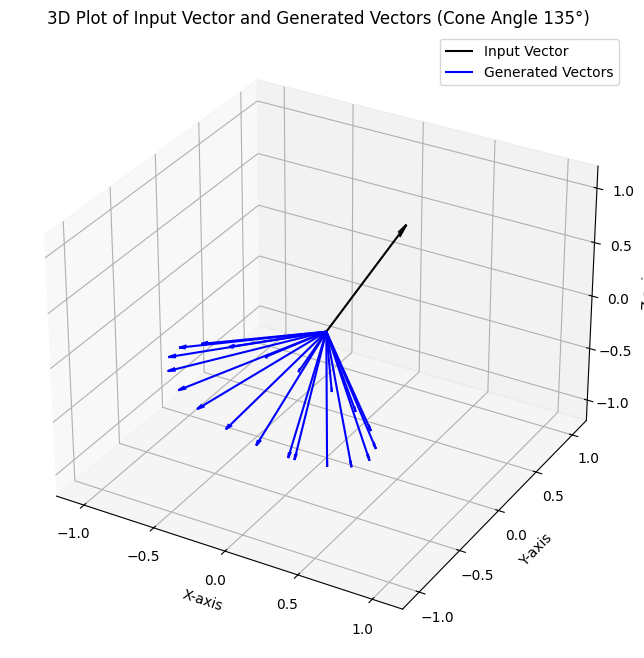

In [382]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the input vector (v)
ax.quiver(0, 0, 0, v[0], v[1], v[2], color='black', label='Input Vector', arrow_length_ratio=0.1)

# Plot a subset (e.g., 20) of the generated vectors
num_vectors_to_plot = 20
sample_indices = np.linspace(0, len(result_vectors_np) - 1, num_vectors_to_plot, dtype=int)

for i, idx in enumerate(sample_indices):
    vec = result_vectors_np[idx]
    if i == 0: # Add label only once for the legend
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color='blue', label='Generated Vectors', arrow_length_ratio=0.05)
    else:
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color='blue', arrow_length_ratio=0.05)

# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Plot of Input Vector and Generated Vectors (Cone Angle 135°)')
ax.legend()

# Set limits to ensure all vectors are visible
max_val = np.max(np.abs(v))
for vec in result_vectors_np:
    max_val = np.max([max_val, np.max(np.abs(vec))])
limit = max_val * 1.2 # Add some padding
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit, limit])


In [383]:
import plotly.graph_objects as go

fig = go.Figure()

# Add the input vector (v)
fig.add_trace(go.Scatter3d(
    x=[0, v[0]], y=[0, v[1]], z=[0, v[2]],
    mode='lines+markers',
    line=dict(color='black', width=4),
    marker=dict(size=4),
    name='Input Vector'
))

# Plot a subset of the generated vectors for clarity
num_vectors_to_plot = 20 # Can adjust this number
sample_indices = np.linspace(0, len(result_vectors_np) - 1, num_vectors_to_plot, dtype=int)

for i, idx in enumerate(sample_indices):
    vec = result_vectors_np[idx]
    fig.add_trace(go.Scatter3d(
        x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
        mode='lines',
        line=dict(color='blue', width=2),
        showlegend=False if i > 0 else True, # Show legend only for the first one
        name='Generated Vectors' if i == 0 else ''
    ))

# Update layout for a better 3D view
fig.update_layout(
    title='Interactive 3D Plot of Input Vector and Generated Vectors (Cone Angle 135°)',
    scene=dict(
        xaxis_title='X-axis',
        yaxis_title='Y-axis',
        zaxis_title='Z-axis',
        aspectmode='cube' # Ensures equal scaling for axes
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

This is how the closest matching vector is found iteratre through to minimise pitch

In [384]:
import numpy as np

# Reuse the calculate_vector_pitch function from the previous cell if it's not already in scope
def calculate_vector_pitch(vector):
    """Calculates the pitch angle from a 3D vector [x, y, z] in degrees.
    Assumes Z is the vertical component and X, Y are horizontal components.
    """
    x, y, z = vector[0], vector[1], vector[2]
    horizontal_magnitude = np.sqrt(x**2 + y**2)
    if horizontal_magnitude == 0:
        return np.degrees(np.arctan2(z, 0.000001)) # Return +/-90 if purely vertical
    return np.degrees(np.arctan2(z, horizontal_magnitude))


target_pitch_radians = ds2_p2
target_pitch_degrees = cnn_p2 #np.degrees(target_pitch_radians)

closest_vector_rad = None
min_pitch_difference_rad = float('inf')
closest_pitch_degrees_rad = None

for vec in result_vectors_np:
    current_pitch_degrees = calculate_vector_pitch(vec)
    pitch_difference_degrees = abs(current_pitch_degrees - target_pitch_degrees)

    if pitch_difference_degrees < min_pitch_difference_rad:
        min_pitch_difference_rad = pitch_difference_degrees
        closest_vector_rad = vec
        closest_pitch_degrees_rad = current_pitch_degrees

print(f"Target Pitch: {target_pitch_radians:.2f} radians ({target_pitch_degrees:.2f} degrees)")
print(f"Vector with Pitch Closest to {target_pitch_radians:.2f} radians:")
print(f"  Vector: {closest_vector_rad}")
print(f"  Calculated Pitch: {closest_pitch_degrees_rad:.2f} degrees (approximately {np.radians(closest_pitch_degrees_rad):.2f} radians)")

Target Pitch: -2.05 radians (4.77 degrees)
Vector with Pitch Closest to -2.05 radians:
  Vector: [ 0.6196424  -0.78078539  0.08010912]
  Calculated Pitch: 4.59 degrees (approximately 0.08 radians)


In [385]:
# Assuming 'v', 'result_vectors_np', 'closest_vector_rad', and 'second_output_vector' are already defined

fig = go.Figure()

# Add the input vector (v)
fig.add_trace(go.Scatter3d(
    x=[0, v[0]], y=[0, v[1]], z=[0, v[2]],
    mode='lines+markers',
    line=dict(color='black', width=4),
    marker=dict(size=4),
    name='Input Vector'
))

# Plot a subset of the generated vectors for context (cone)
num_vectors_to_plot = 30 # Can adjust this number
sample_indices = np.linspace(0, len(result_vectors_np) - 1, num_vectors_to_plot, dtype=int)

for i, idx in enumerate(sample_indices):
    vec = result_vectors_np[idx]
    fig.add_trace(go.Scatter3d(
        x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
        mode='lines',
        line=dict(color='blue', width=1),
        showlegend=False if i > 0 else True,
        name='Generated Cone Vectors'
    ))

# Add the first closest resultant vector
if closest_vector_rad is not None:
    fig.add_trace(go.Scatter3d(
        x=[0, closest_vector_rad[0]], y=[0, closest_vector_rad[1]], z=[0, closest_vector_rad[2]],
        mode='lines+markers',
        line=dict(color='red', width=5),
        marker=dict(size=6, symbol='diamond'),
        name='Closest Pitch Vector'
    ))

# Update layout for a better 3D view
fig.update_layout(
    title='Interactive 3D Plot: Input, Cone, and Output Vectors',
    scene=dict(
        xaxis_title='X-axis',
        yaxis_title='Y-axis',
        zaxis_title='Z-axis',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [386]:
def calculate_yaw(vector):
    """Calculates the yaw angle from a 3D vector [x, y, z] in degrees.
    Assumes yaw is the angle in the XY-plane relative to the positive X-axis.
    """
    x, y = vector[0], vector[1]
    # np.arctan2(y, x) computes the angle in radians, then convert to degrees
    return np.degrees(np.arctan2(y, x))

# Calculate yaw for the input vector 'v'
yaw_v = calculate_yaw(v)

# Calculate yaw for the closest resultant vector 'closest_vector_rad'
yaw_closest_vector = calculate_yaw(closest_vector_rad)

# Calculate the absolute difference in yaw angles
yaw_difference = abs(yaw_v - yaw_closest_vector)

print(f"Yaw angle of the input vector (v): {yaw_v:.2f} degrees")
print(f"Yaw angle of the closest output vector: {yaw_closest_vector:.2f} degrees")
print(f"Absolute difference in yaw angles: {yaw_difference:.2f} degrees")

Yaw angle of the input vector (v): 90.00 degrees
Yaw angle of the closest output vector: -51.56 degrees
Absolute difference in yaw angles: 141.56 degrees




---


BELOW results converted to radians for plotting (essentially like a part three)


---



In [387]:
gt_pitch1 = -25*np.pi / 180
gt_pitch2 = 0
gt_pitch3 = 0

gt_yaw1 = 0
gt_yaw2 = 40.6*np.pi / 180
gt_yaw3 = 130.6*np.pi / 180

In [388]:
ds1_pitch1 = -24.29*np.pi / 180
ds1_pitch2 = 4.46*np.pi / 180
ds1_pitch3 = 5.38*np.pi / 180

ds1_yaw1 = 0
ds1_yaw2 = 35.02*np.pi / 180
ds1_yaw3 = 125*np.pi / 180

In [389]:
cnn_p1 = -21.17973602611441
cnn_p2 = 4.77
cnn_p3 = 5.033281731961962

cnn_pitch1 = cnn_p1*np.pi / 180
cnn_pitch2 = cnn_p2*np.pi / 180
cnn_pitch3 = cnn_p3*np.pi / 180

cnn_yaw1 = 0
cnn_yaw2 = 44.52*np.pi / 180
cnn_yaw3 = 130.09*np.pi / 180

In [390]:
#run if you want to test CNN as ds2

ds2_pitch1 = cnn_p1*np.pi / 180
ds2_pitch2 = cnn_p2*np.pi / 180
ds2_pitch3 = cnn_p3*np.pi / 180

ds2_yaw1 = 0
ds2_yaw2 = 44.52*np.pi / 180
ds2_yaw3 = 130.09*np.pi / 180



In [391]:
ds2_pitch1 = -25.31*np.pi / 180
ds2_pitch2 = -1.73*np.pi / 180
ds2_pitch3 = 5.40*np.pi / 180

ds2_yaw1 = 0
ds2_yaw2 = 39.8*np.pi / 180
ds2_yaw3 = 129.64*np.pi / 180

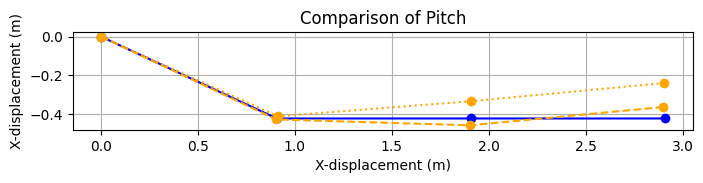

In [392]:
plt.figure(figsize=(8, 6))

# Plot Model path
gt_x = [0, np.cos(gt_pitch1), np.cos(gt_pitch1) + np.cos(gt_pitch2), np.cos(gt_pitch1) + np.cos(gt_pitch2) + np.cos(gt_pitch3)]
gt_y = [0, np.sin(gt_pitch1), np.sin(gt_pitch1) + np.sin(gt_pitch2), np.sin(gt_pitch1) + np.sin(gt_pitch2) + np.sin(gt_pitch3)]
plt.plot(gt_x, gt_y, marker='o', linestyle='-', color='blue', label='Truth')

# Plot DS1 path
ds1_x = [0, np.cos(ds1_pitch1), np.cos(ds1_pitch1) + np.cos(ds1_pitch2), np.cos(ds1_pitch1) + np.cos(ds1_pitch2) + np.cos(ds1_pitch3)]
ds1_y = [0, np.sin(ds1_pitch1), np.sin(ds1_pitch1) + np.sin(ds1_pitch2), np.sin(ds1_pitch1) + np.sin(ds1_pitch2) + np.sin(ds1_pitch3)]
plt.plot(ds1_x, ds1_y, marker='o', linestyle=':', color='orange', label='DS1')

# Plot DS2 path
ds2_x = [0, np.cos(ds2_pitch1), np.cos(ds2_pitch1) + np.cos(ds2_pitch2), np.cos(ds2_pitch1) + np.cos(ds2_pitch2) + np.cos(ds2_pitch3)]
ds2_y = [0, np.sin(ds2_pitch1), np.sin(ds2_pitch1) + np.sin(ds2_pitch2), np.sin(ds2_pitch1) + np.sin(ds2_pitch2) + np.sin(ds2_pitch3)]
plt.plot(ds2_x, ds2_y, marker='o', linestyle='--', color='orange', label='DS2')

plt.title('Comparison of Pitch')
plt.xlabel('X-displacement (m)')
plt.ylabel('X-displacement (m)')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal scaling for x and y axes
#plt.legend(loc = 'upper right')
plt.show()

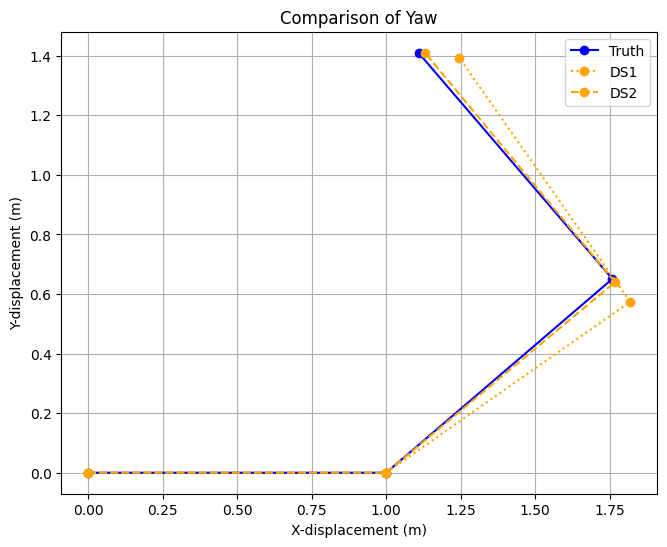

In [393]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Plot Model path
gt_x = [0, np.cos(gt_yaw1), np.cos(gt_yaw1) + np.cos(gt_yaw2), np.cos(gt_yaw1) + np.cos(gt_yaw2) + np.cos(gt_yaw3)]
gt_y = [0, np.sin(gt_yaw1), np.sin(gt_yaw1) + np.sin(gt_yaw2), np.sin(gt_yaw1) + np.sin(gt_yaw2) + np.sin(gt_yaw3)]
plt.plot(gt_x, gt_y, marker='o', linestyle='-', color='blue', label='Truth')

# Plot DS1 path
ds1_x = [0, np.cos(ds1_yaw1), np.cos(ds1_yaw1) + np.cos(ds1_yaw2), np.cos(ds1_yaw1) + np.cos(ds1_yaw2) + np.cos(ds1_yaw3)]
ds1_y = [0, np.sin(ds1_yaw1), np.sin(ds1_yaw1) + np.sin(ds1_yaw2), np.sin(ds1_yaw1) + np.sin(ds1_yaw2) + np.sin(ds1_yaw3)]
plt.plot(ds1_x, ds1_y, marker='o', linestyle=':', color='orange', label='DS1')

# Plot DS2 path
ds2_x = [0, np.cos(ds2_yaw1), np.cos(ds2_yaw1) + np.cos(ds2_yaw2), np.cos(ds2_yaw1) + np.cos(ds2_yaw2) + np.cos(ds2_yaw3)]
ds2_y = [0, np.sin(ds2_yaw1), np.sin(ds2_yaw1) + np.sin(ds2_yaw2), np.sin(ds2_yaw1) + np.sin(ds2_yaw2) + np.sin(ds2_yaw3)]
plt.plot(ds2_x, ds2_y, marker='o', linestyle='--', color='orange', label='DS2')

plt.title('Comparison of Yaw')
plt.xlabel('X-displacement (m)')
plt.ylabel('Y-displacement (m)')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal scaling for x and y axes
plt.legend(loc = 'upper right')
plt.show()

In [394]:
ds1_d1 = 493.38 + 250
ds1_d2 = 204.87
ds1_d3 = 45.66 + 250

ds2_d1 = 492.83 + 250
ds2_d2 = 249.77
ds2_d3 = 186.67 + 250

cnn_d1 = 473.50176857841313 + 250
cnn_d2 = 221.2847425123913
cnn_d3 = 32.827313317990274 + 250



In [395]:
d1 = 493.38 + 250
e1 = 204.87

d2 = 492.83 + 250
e2 = 249.77

d3 = 493.84 + 250
e3 = 283.87

d = (d1 + d2 + d3)/3
error1 = 750 - d
print(error1)

e = (e1 + e2 + e3)/3
print(300 - e)

6.649999999999977
53.83000000000001


**MAIN PLOT** **FUNCTION**

In [396]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline

# Helper function to convert spherical coordinates to Cartesian
def spherical_to_cartesian(length, pitch, yaw):
    """Converts spherical coordinates (length, pitch, yaw) to Cartesian [x, y, z].
    Pitch: angle with the XY-plane (elevation).
    Yaw: angle in the XY-plane relative to the positive X-axis (azimuth).
    """
    x = length * np.cos(pitch) * np.cos(yaw)
    y = length * np.cos(pitch) * np.sin(yaw)
    z = length * np.sin(pitch)
    return np.array([x, y, z])

# Define vector length
gt_vector_length_1 = 750
gt_vector_length_2 = 300
gt_vector_length_3 = 400

# Define vector length
ds1_vector_length_1 = ds1_d1
ds1_vector_length_2 = ds1_d2
ds1_vector_length_3 = 400

# Define vector length
ds2_vector_length_1 = cnn_d1
ds2_vector_length_2 = cnn_d2
ds2_vector_length_3 = 400


# Initialize current position and list to store path points for Ground Truth (gt)
current_position_gt = np.array([0.0, 0.0, 0.0])
path_points_gt = [current_position_gt.tolist()] # Start with the origin

# Calculate and add the first vector for gt
vector1_gt = spherical_to_cartesian(gt_vector_length_1, gt_pitch1, -gt_yaw1)
current_position_gt = current_position_gt + vector1_gt
path_points_gt.append(current_position_gt.tolist())

# CREATE ELBOW ------------------------------------------

# 2. Define the three control points
control_point1 = current_position_gt

# This is the end of the second segment if it were discrete
vector2_gt_discrete = spherical_to_cartesian(15, gt_pitch1, -gt_yaw1)
control_point2 = control_point1 + vector2_gt_discrete

# This is the end of the third segment if it were discrete
vector3_gt_discrete = spherical_to_cartesian(15, gt_pitch2, -gt_yaw2)
control_point3 = control_point2 + vector3_gt_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_gt = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_gt.extend(path_points_arc.tolist())

#-------------------- el

# Calculate and add the second vector for gt
vector2_gt = spherical_to_cartesian(gt_vector_length_2, gt_pitch2, -gt_yaw2)
current_position_gt = current_position_gt + vector2_gt
path_points_gt.append(current_position_gt.tolist())

## CREATE ARCH -------------------------------------------------------------

# 2. Define the three control points
control_point1 = current_position_gt

# This is the end of the second segment if it were discrete
vector2_gt_discrete = spherical_to_cartesian(40, gt_pitch2, -gt_yaw2)
control_point2 = control_point1 + vector2_gt_discrete

# This is the end of the third segment if it were discrete
vector3_gt_discrete = spherical_to_cartesian(40, gt_pitch3, -gt_yaw3)
control_point3 = control_point2 + vector3_gt_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_gt = path_points_arc[-1]
compare_gt = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_gt.extend(path_points_arc.tolist())

#-----

# Calculate and add the third vector for gt
vector3_gt = spherical_to_cartesian(gt_vector_length_3, gt_pitch3, -gt_yaw3)
current_position_gt = current_position_gt + vector3_gt
path_points_gt.append(current_position_gt.tolist())

# Convert path_points_gt to a numpy array for easier plotting
path_points_gt = np.array(path_points_gt)

#--------------------------------------------------------------------------

# Initialize current position and list to store path points for DS1
current_position_ds1 = np.array([0.0, 0.0, 0.0])
path_points_ds1 = [current_position_ds1.tolist()] # Start with the origin

# Calculate and add the first vector for ds1
vector1_ds1 = spherical_to_cartesian(ds1_vector_length_1, ds1_pitch1, -ds1_yaw1)
current_position_ds1 = current_position_ds1 + vector1_ds1
path_points_ds1.append(current_position_ds1.tolist())

# CREATE ELBOW ------------------------------------------

# 2. Define the three control points
control_point1 = current_position_ds1

# This is the end of the second segment if it were discrete
vector2_ds1_discrete = spherical_to_cartesian(15, ds1_pitch1, -ds1_yaw1)
control_point2 = control_point1 + vector2_ds1_discrete

# This is the end of the third segment if it were discrete
vector3_ds1_discrete = spherical_to_cartesian(15, ds1_pitch2, -ds1_yaw2)
control_point3 = control_point2 + vector3_ds1_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_ds1 = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_ds1.extend(path_points_arc.tolist())

#-------------------- el

# Calculate and add the second vector for ds1
vector2_ds1 = spherical_to_cartesian(ds1_vector_length_2, ds1_pitch2, -ds1_yaw2)
current_position_ds1 = current_position_ds1 + vector2_ds1
path_points_ds1.append(current_position_ds1.tolist())

## CREATE ARCH -------------------------------------------------------------

# 2. Define the three control points
control_point1 = current_position_ds1

# This is the end of the second segment if it were discrete
vector2_ds1_discrete = spherical_to_cartesian(40, ds1_pitch2, -ds1_yaw2)
control_point2 = control_point1 + vector2_ds1_discrete

# This is the end of the third segment if it were discrete
vector3_ds1_discrete = spherical_to_cartesian(40, ds1_pitch3, -ds1_yaw3)
control_point3 = control_point2 + vector3_ds1_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_ds1 = path_points_arc[-1]
compare_ds1 = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_ds1.extend(path_points_arc.tolist())

#-----

# Calculate and add the third vector for ds1
vector3_ds1 = spherical_to_cartesian(ds1_vector_length_3, ds1_pitch3, -ds1_yaw3)
current_position_ds1 = current_position_ds1 + vector3_ds1
path_points_ds1.append(current_position_ds1.tolist())

# Convert path_points_ds1 to a numpy array for easier plotting
path_points_ds1 = np.array(path_points_ds1)


#-------------------------------------------------------------------------
# Initialize current position for DS2
current_position_ds2 = np.array([0.0, 0.0, 0.0])
path_points_ds2 = [current_position_ds2.tolist()] # Start with the origin

# Calculate and add the first vector for ds2 (initial straight segment)
vector1_ds2 = spherical_to_cartesian(ds2_vector_length_1, ds2_pitch1, -ds2_yaw1)
current_position_ds2 = current_position_ds2 + vector1_ds2
path_points_ds2.append(current_position_ds2.tolist())

# CREATE ELBOW ------------------------------------------

# 2. Define the three control points
control_point1 = current_position_ds2

# This is the end of the second segment if it were discrete
vector2_ds2_discrete = spherical_to_cartesian(15, ds2_pitch1, -ds2_yaw1)
control_point2 = control_point1 + vector2_ds2_discrete

# This is the end of the third segment if it were discrete
vector3_ds2_discrete = spherical_to_cartesian(15, ds2_pitch2, -ds2_yaw2)
control_point3 = control_point2 + vector3_ds2_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_ds2 = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_ds2.extend(path_points_arc.tolist())

#-------------------- el

# Calculate and add the second vector for ds2
vector2_ds2 = spherical_to_cartesian(ds2_vector_length_2, ds2_pitch2, -ds2_yaw2)
current_position_ds2 = current_position_ds2 + vector2_ds2
path_points_ds2.append(current_position_ds2.tolist())

## CREATE ARCH -------------------------------------------------------------

# 2. Define the three control points
control_point1 = current_position_ds2

# This is the end of the second segment if it were discrete
vector2_ds2_discrete = spherical_to_cartesian(40, ds2_pitch2, -ds2_yaw2)
control_point2 = control_point1 + vector2_ds2_discrete

# This is the end of the third segment if it were discrete
vector3_ds2_discrete = spherical_to_cartesian(40, ds2_pitch3, -ds2_yaw3)
control_point3 = control_point2 + vector3_ds2_discrete

# 3. Create a parameter array for the spline
t = np.array([0, 1, 2])

# 4. Create CubicSpline instances for each coordinate (x, y, z)
cs_x = CubicSpline(t, [control_point1[0], control_point2[0], control_point3[0]])
cs_y = CubicSpline(t, [control_point1[1], control_point2[1], control_point3[1]])
cs_z = CubicSpline(t, [control_point1[2], control_point2[2], control_point3[2]])

# 5. Generate a denser array of 'time' values
t_dense = np.linspace(0, 2, 100) # 100 points for a smoother curve

# 6. Evaluate each CubicSpline instance with t_dense
arc_x = cs_x(t_dense)
arc_y = cs_y(t_dense)
arc_z = cs_z(t_dense)

# 7. Combine these interpolated coordinates into a single NumPy array
path_points_arc = np.vstack((arc_x, arc_y, arc_z)).T

# The final position of DS2 after the arc is the last point of the spline
current_position_ds2 = path_points_arc[-1]
compare_ds2 = path_points_arc[-1]

# The path_points_ds2 should now start with the initial straight segment
# and then extend the interpolated arc points.
path_points_ds2.extend(path_points_arc.tolist())

# -----------------------------------------------------------------------
# Calculate and add the third vector for ds2
vector3_ds2 = spherical_to_cartesian(ds2_vector_length_3, ds2_pitch3, -ds2_yaw3)
current_position_ds2 = current_position_ds2 + vector3_ds2
path_points_ds2.append(current_position_ds2.tolist())


# Convert path_points_ds2 to a numpy array for easier plotting
path_points_ds2 = np.array(path_points_ds2)

# Create the 3D plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=path_points_gt[:, 0],
            y=path_points_gt[:, 1],
            z=path_points_gt[:, 2],
            mode='lines+markers',
            marker=dict(size=5, color='blue'),
            line=dict(color='blue', width=7),
            name='Ground Truth Path'
        ),
        go.Scatter3d(
            x=path_points_ds1[:, 0],
            y=path_points_ds1[:, 1],
            z=path_points_ds1[:, 2],
            mode='lines+markers',
            marker=dict(size=5, color='orange'),
            line=dict(color='orange', width=7),
            name='DS1 Path'
        ),
        go.Scatter3d(
            x=path_points_ds2[:, 0],
            y=path_points_ds2[:, 1],
            z=path_points_ds2[:, 2],
            mode='lines+markers',
            marker=dict(size=5, color='pink'),
            line=dict(color='pink', width=7),
            name='DS1 after CNN Characterisation Path'
        )
    ]
)

# Update layout for better visualization
fig.update_layout(
    title='3D Tube Path with Ground Truth, DS1, and DS2 Pitch and Yaw',
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.5)
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
print("Generated 3D plot for ground truth, DS1, and DS2 vectors.")

Generated 3D plot for ground truth, DS1, and DS2 vectors.


quaternion bit......

In [397]:
import numpy as np

def euler_to_quaternion(phi, theta, psi):
    """Converts Euler angles (roll, pitch, yaw) to a quaternion.

    Args:
        phi (float): Roll angle (φ) in radians.
        theta (float): Pitch angle (θ) in radians.
        psi (float): Yaw angle (ψ) in radians.

    Returns:
        numpy.ndarray: A 4-element array representing the quaternion [q0, q1, q2, q3].
    """
    c_phi_2 = np.cos(phi / 2)
    s_phi_2 = np.sin(phi / 2)
    c_theta_2 = np.cos(theta / 2)
    s_theta_2 = np.sin(theta / 2)
    c_psi_2 = np.cos(psi / 2)
    s_psi_2 = np.sin(psi / 2)

    q0 = c_phi_2 * c_theta_2 * c_psi_2 + s_phi_2 * s_theta_2 * s_psi_2
    q1 = s_phi_2 * c_theta_2 * c_psi_2 - c_phi_2 * s_theta_2 * s_psi_2
    q2 = c_phi_2 * s_theta_2 * c_psi_2 + s_phi_2 * c_theta_2 * s_psi_2
    q3 = c_phi_2 * c_theta_2 * s_psi_2 - s_phi_2 * s_theta_2 * c_psi_2

    return np.array([q0, q1, q2, q3])

print("Function 'euler_to_quaternion' defined successfully.")

Function 'euler_to_quaternion' defined successfully.


In [398]:
import numpy as np

def quaternion_multiply(q1, q2):
    """Performs quaternion multiplication of two quaternions."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2

    w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2

    return np.array([w, x, y, z])

def euler_rodrigues_quaternion_update(q_initial, gyro_x, gyro_y, gyro_z, dt):
    """Updates the quaternion using Euler-Rodrigues formula with angular velocities.

    Args:
        q_initial (np.ndarray): Initial quaternion [w, x, y, z].
        gyro_x (float): Angular velocity around X-axis.
        gyro_y (float): Angular velocity around Y-axis.
        gyro_z (float): Angular velocity around Z-axis.
        dt (float): Time step.

    Returns:
        np.ndarray: Updated and normalized quaternion.
    """
    # 1. Convert angular velocities to a quaternion (pure quaternion with scalar part 0)
    omega_quat = np.array([0.0, gyro_x, gyro_y, gyro_z])

    # 2. Calculate the derivative of the quaternion: q_dot = 0.5 * q * omega
    q_dot = 0.5 * quaternion_multiply(q_initial, omega_quat)

    # 3. Compute the updated quaternion: q_new = q_initial + q_dot * dt
    q_new = q_initial + q_dot * dt

    # 4. Normalize the new quaternion to ensure it remains a unit quaternion
    q_new = q_new / np.linalg.norm(q_new)

    return q_new

print("Functions 'quaternion_multiply' and 'euler_rodrigues_quaternion_update' defined successfully.")

Functions 'quaternion_multiply' and 'euler_rodrigues_quaternion_update' defined successfully.


copy accross data to new df

In [399]:
df_output = new_df_imu[['timestamp2', 'gyroX', 'gyroY', 'gyroZ', 'Combined_Pitch_Variable', 'Combined_Roll_Variable', 'straight','dx2']].copy()
display(df_output.head(100))

,timestamp2,gyroX,gyroY,gyroZ,Combined_Pitch_Variable,Combined_Roll_Variable,straight,dx2
0,0,1.25,0.12,1.63,NaN,NaN,1,NaN
1,97,1.12,0.19,1.44,NaN,NaN,1,NaN
2,226,1.37,0.06,1.50,NaN,NaN,1,4.130643e-06
3,323,1.44,0.31,1.56,NaN,NaN,1,-6.030139e-07
4,419,1.31,0.31,1.56,NaN,NaN,1,1.943444e-06
...,...,...,...,...,...,...,...,...
95,10302,-0.37,0.63,-3.25,-20.862023,20.23042,1,2.115222e-03
96,10399,-0.44,0.94,-3.31,-20.862023,20.23042,1,-1.120826e-02
97,10527,2.56,-0.56,2.63,-20.862023,20.23042,1,9.558090e-04
98,10623,1.25,-0.88,2.88,-20.862023,20.23042,1,-7.264406e-03


'moving' here is where its acceleration so we dont integrate where its stationary

In [400]:
df_output['moving'] = ((df_output['dx2'] > 0.2) | (df_output['dx2'] < -0.2)).astype(int)
display(df_output.head(100))

,timestamp2,gyroX,gyroY,gyroZ,Combined_Pitch_Variable,Combined_Roll_Variable,straight,dx2,moving
0,0,1.25,0.12,1.63,NaN,NaN,1,NaN,0
1,97,1.12,0.19,1.44,NaN,NaN,1,NaN,0
2,226,1.37,0.06,1.50,NaN,NaN,1,4.130643e-06,0
3,323,1.44,0.31,1.56,NaN,NaN,1,-6.030139e-07,0
4,419,1.31,0.31,1.56,NaN,NaN,1,1.943444e-06,0
...,...,...,...,...,...,...,...,...,...
95,10302,-0.37,0.63,-3.25,-20.862023,20.23042,1,2.115222e-03,0
96,10399,-0.44,0.94,-3.31,-20.862023,20.23042,1,-1.120826e-02,0
97,10527,2.56,-0.56,2.63,-20.862023,20.23042,1,9.558090e-04,0
98,10623,1.25,-0.88,2.88,-20.862023,20.23042,1,-7.264406e-03,0


OKAY SO MAIN FUNCTION - here we integrate and then basically take q3 (z) and scale it against the size of the argument, classic gyro integration situation

In [404]:
sample_period_s = 0.01

num_rows = len(df_output)
q_updated_mat = np.zeros((num_rows, 4))


def euler_to_qg(roll_deg, pitch_deg):
    phi = np.radians(roll_deg)
    theta = np.radians(pitch_deg)
    psi = 0.0  # Heading is initialized to 0 straight ahead

    c_phi_2 = np.cos(phi / 2)
    s_phi_2 = np.sin(phi / 2)
    c_theta_2 = np.cos(theta / 2)
    s_theta_2 = np.sin(theta / 2)
    c_psi_2 = np.cos(psi / 2)
    s_psi_2 = np.sin(psi / 2)

    q0 = c_phi_2 * c_theta_2 * c_psi_2 + s_phi_2 * s_theta_2 * s_psi_2
    q1 = s_phi_2 * c_theta_2 * c_psi_2 - c_phi_2 * s_theta_2 * s_psi_2
    q2 = c_phi_2 * s_theta_2 * c_psi_2 + s_phi_2 * c_theta_2 * c_psi_2
    q3 = c_phi_2 * c_theta_2 * s_psi_2 - s_phi_2 * s_theta_2 * c_psi_2
    return np.array([q0, q1, q2, q3])

# Calculate the initial quaternion for the first row dynamically from raw variables
q_updated_mat[0] = euler_to_qg(
    new_df_imu.loc[0, 'Combined_Roll_Variable'],
    new_df_imu.loc[0, 'Combined_Pitch_Variable']
)

# Quaternion integration
def step_quaternion(q, gx, gy, gz, dt):
    w1, x1, y1, z1 = q
    w2, x2, y2, z2 = 0.0, gx, gy, gz # Gyro rates pure quaternion

    dw = 0.5 * (w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2)
    dx = 0.5 * (w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2)
    dy = 0.5 * (w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2)
    dz = 0.5 * (w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2)

    q_new = np.array([w1 + dw * dt, x1 + dx * dt, y1 + dy * dt, z1 + dz * dt])
    return q_new / np.linalg.norm(q_new)

# --- 2. The Core Update Loop ---
for i in range(1, num_rows):
    if df_output.loc[i, 'straight'] != 1 and df_output.loc[i, 'moving'] == 1:
        # Inside junction and moving: Integrate raw gyro rates
        q_updated_mat[i] = step_quaternion(
            q_updated_mat[i-1],
            new_df_imu.loc[i, 'gyroX'],
            new_df_imu.loc[i, 'gyroY'],
            new_df_imu.loc[i, 'gyroZ'],
            sample_period_s
        )
    elif df_output.loc[i, 'straight'] == 1:
        # Moving straight: Generate qg alignment values directly on the fly
        q_updated_mat[i] = euler_to_qg(
            new_df_imu.loc[i, 'Combined_Roll_Variable'],
            new_df_imu.loc[i, 'Combined_Pitch_Variable']
        )
    else:
        # Stationary inside the junction: Hold orientation constant
        q_updated_mat[i] = q_updated_mat[i-1]

# Assign integrated quaternions back to the DataFrame
df_output['q_updated_0'] = q_updated_mat[:, 0]
df_output['q_updated_1'] = q_updated_mat[:, 1]
df_output['q_updated_2'] = q_updated_mat[:, 2]
df_output['q_updated_3'] = q_updated_mat[:, 3]

# --- 3. Vectorized Turning Geometry & Size Penalty Calculation ---
# Extract total rotation magnitude (argument)
q_w_clamped = df_output['q_updated_0'].clip(-1.0, 1.0)
df_output['quat_argument_deg'] = np.degrees(2 * np.arccos(q_w_clamped))

# The dot product is literally just q3 as in q dot z
# Positive = Clockwise yaw turn, Negative = Anticlockwise yaw turn
df_output['vec_dot_z'] = df_output['q_updated_3']

# Depending on how big of a turn is we'll create a variable for plotting thats scaled
df_output['psi_j_penalized'] = df_output['quat_argument_deg'] * df_output['vec_dot_z']

print("Successfully calculated integrated orientation and size-penalised yaw profiles.")
display(df_output[['straight', 'moving', 'quat_argument_deg', 'vec_dot_z', 'psi_j_penalized']].head())


Successfully calculated integrated orientation and size-penalised yaw profiles.


,straight,moving,quat_argument_deg,vec_dot_z,psi_j_penalized
0,1,0,NaN,NaN,NaN
1,1,0,NaN,NaN,NaN
2,1,0,NaN,NaN,NaN
3,1,0,NaN,NaN,NaN
4,1,0,NaN,NaN,NaN


Positive Z is indicative of right turn, its cumalative so the end of the junction the 2nd and 4th devisions we see its net poz meaning its right for both (correct)

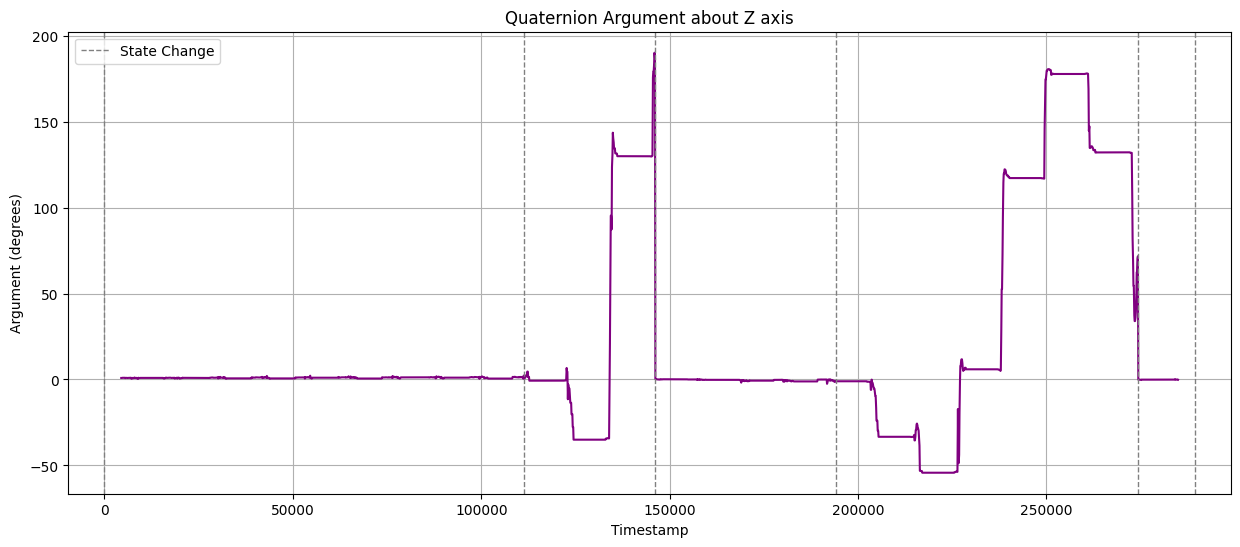

In [405]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df_output['timestamp2'], df_output['psi_j_penalized'], color='purple')
plt.title('Quaternion Argument about Z axis')

# Add vertical lines for timestamps_at_state_1_changes
for timestamp in timestamps_at_state_1_changes:
    plt.axvline(x=timestamp, color='gray', linestyle='--', linewidth=1, label='State Change' if timestamp == timestamps_at_state_1_changes[0] else "")

plt.xlabel('Timestamp')
plt.ylabel('Argument (degrees)')
plt.legend()
plt.grid(True)
plt.show()